In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [6]:
project='Orlanski'
ed='run2/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

var='dynDiag'

ds=xr.open_dataset(str(location) +  str(var) + '.nc')


varS='surfDiag'

dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(ds.Y)
nx=len(ds.X) 
nz=len(ds.diag_levels)
nt=len(ds.T) 

umbral=ny*0.5

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']

start=np.where(ds.T/(60*60*24*360)>0.1)[0][0]
end = np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1]


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=10
    OBend=-1
    OBx=1
    OBendx=-1

In [4]:
params = {'font.size': 15,
          'figure.figsize': (20, 20),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

In [9]:
int(tsteps[i])

0

/var/folders/fl/w6vkfnfn7c17jtg6gqg_hb0w0000gn/T/ipykernel_8572/1379080789.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


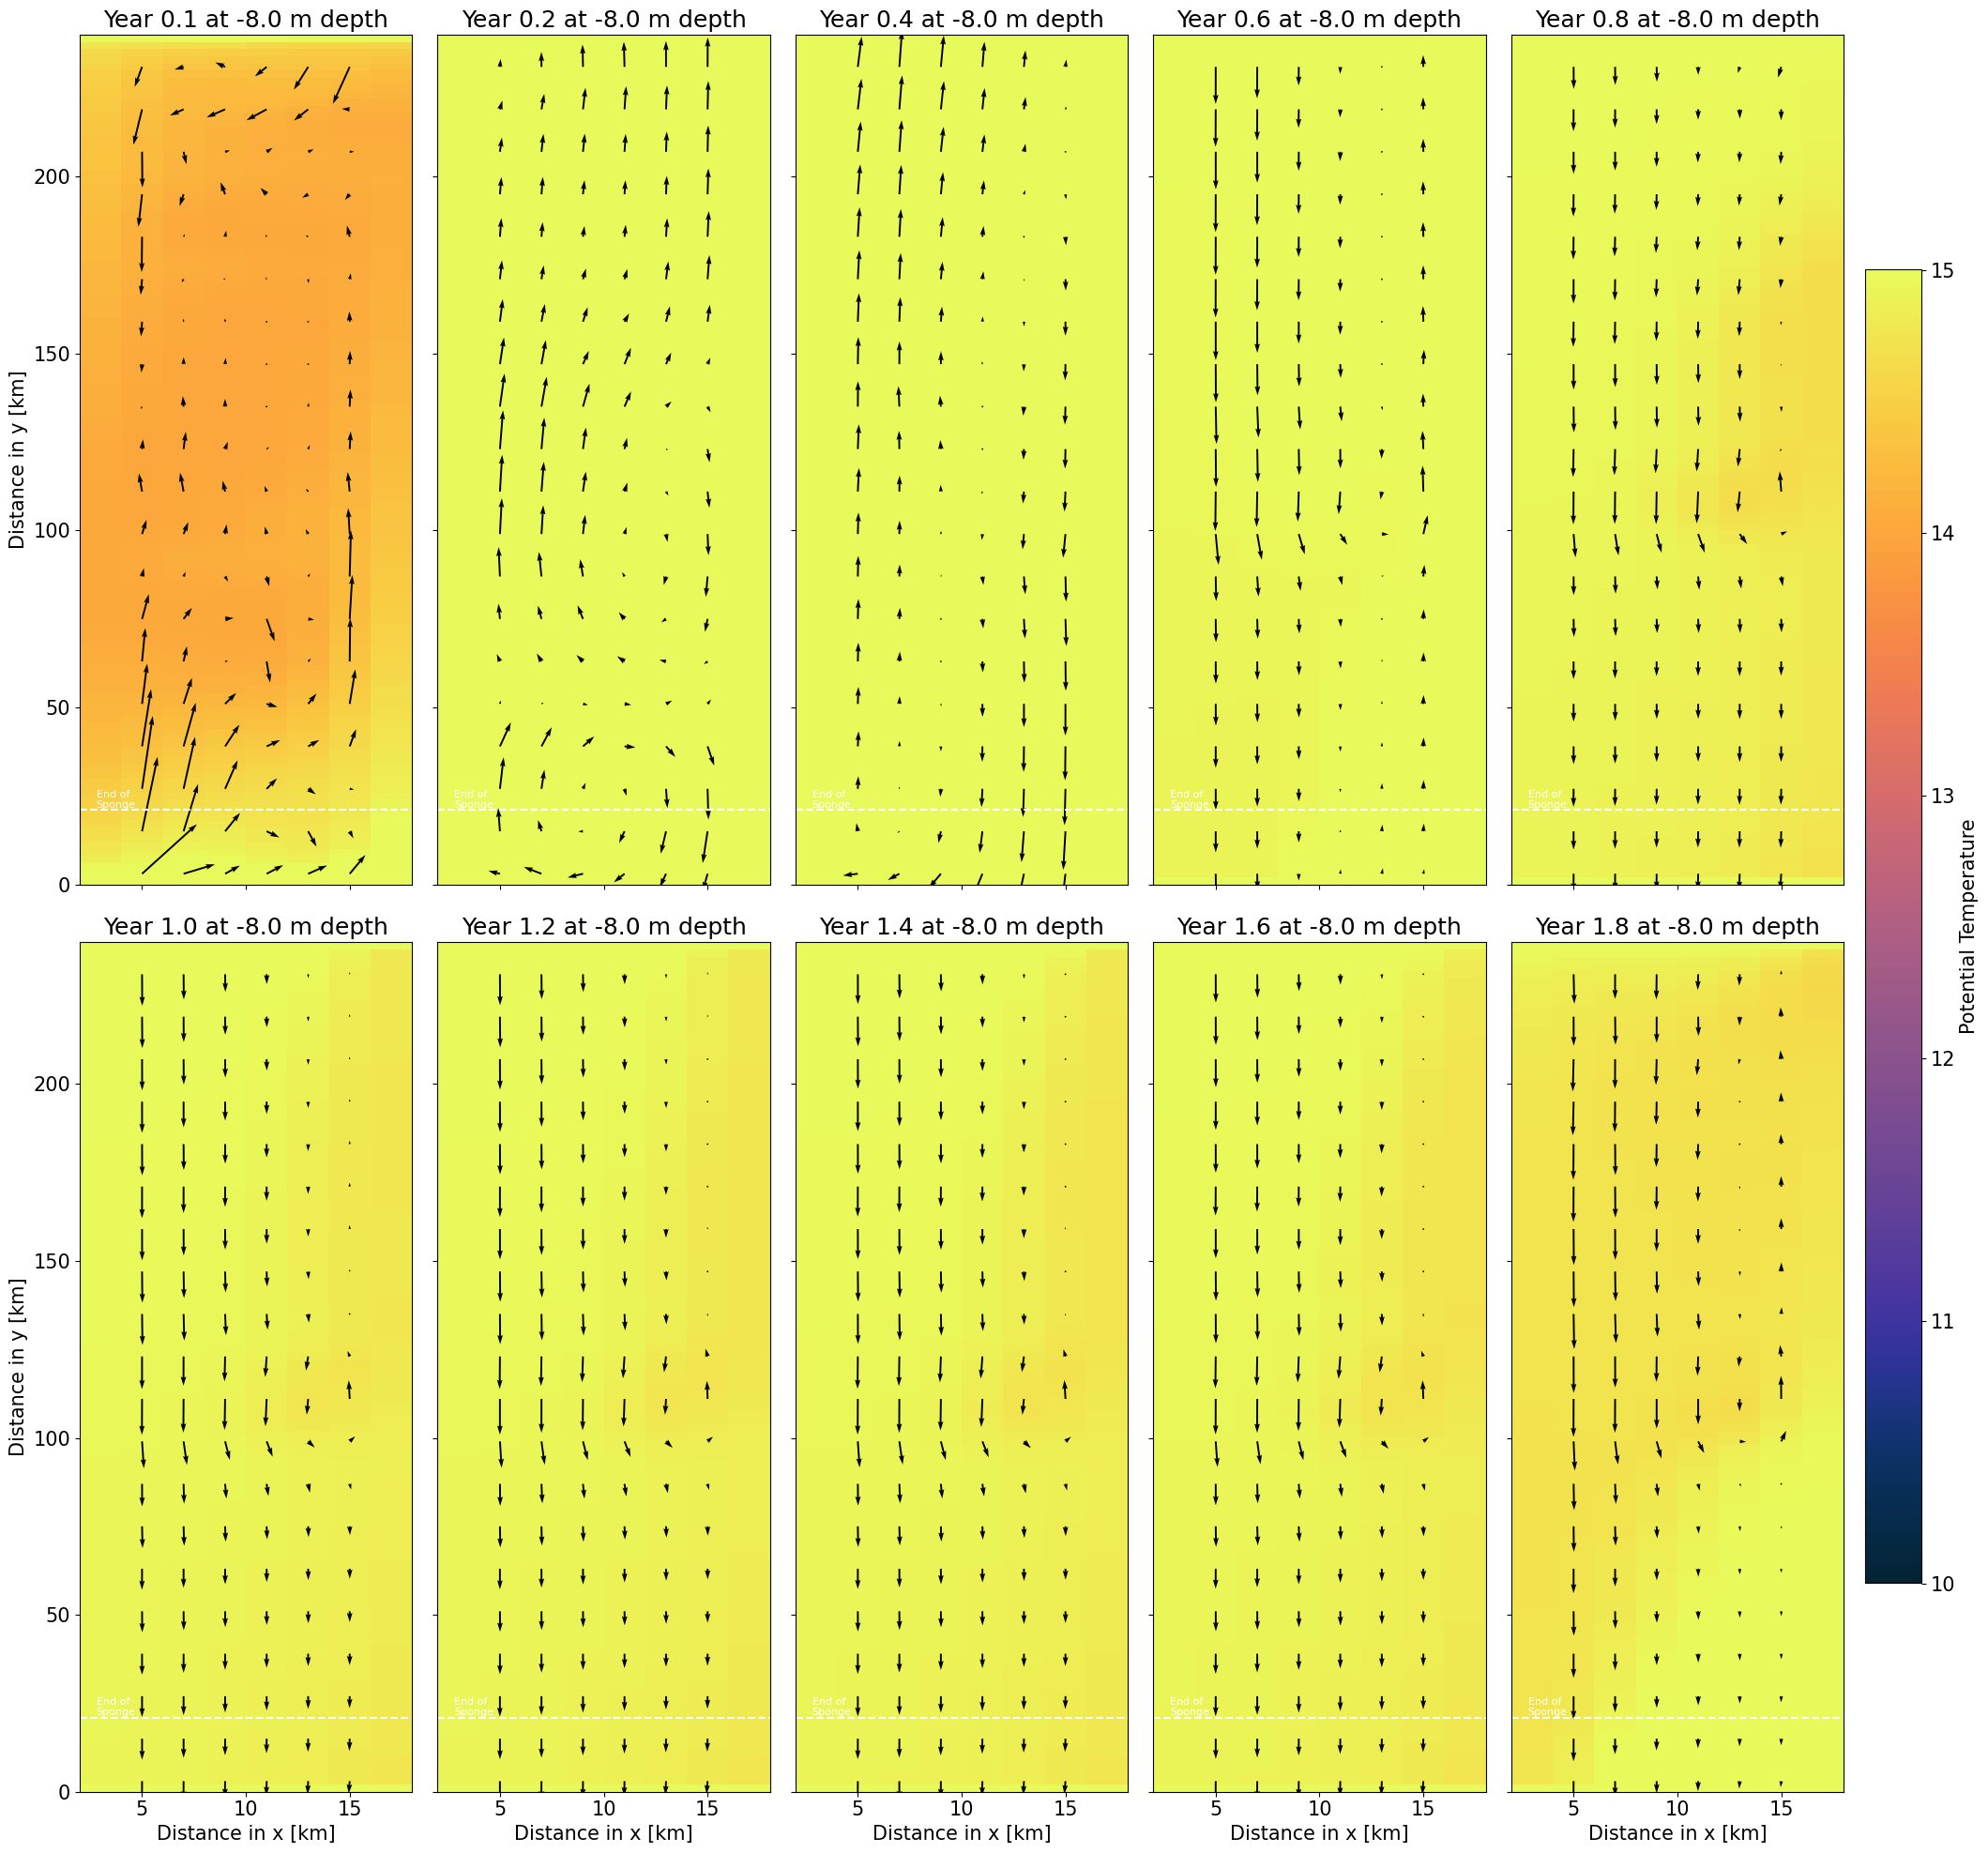

In [10]:
t=0
space=6
dep=0
VARS=list(ds.keys())[2:]

divT=(60*60*24*360)
unit= 'Years'
tsteps=np.arange(0,len(ds.T[:end]),len(ds.T[:end])/10)

#for variable in VARS:

variable=VARS[0]

exec(f'varin=ds.{variable}')
title= varin.description 
if variable == 'VVEL' :
    Yin=dsG.Yp1
else:
    Yin=dsG.Y
if variable == 'UVEL' :
    Xin=dsG.Xp1[OBx:OBendx]
else:
    Xin=dsG.X[OBx:OBendx]

if variable == 'THETA':
    vmin=10
    vmax=15
    cmapi=cmocean.cm.thermal
elif variable == 'PHIHYD':
    vmin=np.min(varin[3].values)
    vmax=-np.min(varin[3].values)
    cmapi=cmocean.cm.delta
elif variable == 'WVEL': 
    vmin=np.min(varin.values)
    vmax=-np.min(varin.values)
    cmapi=cmocean.cm.balance
else: 
    vmin=np.min(varin)
    vmax=-np.min(varin)
    cmapi=cmocean.cm.balance

levels=np.linspace(vmin,vmax,15)

fig,ax=plt.subplots(2,5)

for i in range(10):
    tin=int(tsteps[i])
    if i<=4:
        axin=ax[0,i]
        axin.xaxis.set_tick_params(labelbottom=False)
    elif np.logical_and(i>4,i<=9):
        axin=ax[1,i-5]
        axin.set(xlabel='Distance in x [km]')
    if i==0 or i==10 or i==5 :
        axin.set(ylabel='Distance in y [km]')
    else: 
        axin.yaxis.set_tick_params(labelleft=False)


    timein=ds.T[tin]/(60*60*24)
    cax0=axin.pcolormesh(Xin/1000, Yin/1000, varin[tin,dep,:,OBx:OBendx],vmin=vmin,vmax=vmax,cmap=cmapi)
    axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep]:.1f} m depth')


    gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

    interpV=sciint.RegularGridInterpolator((ds.Yp1.values,ds.X.values),ds.VVEL[tin,dep,:,:].values)
    V=interpV((gridY,gridX))

    interpU=sciint.RegularGridInterpolator((ds.Y.values,ds.Xp1.values),ds.UVEL[tin,dep,:,:].values)
    U=interpU((gridY,gridX))

    axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

    if project =='OpenNorth':
        axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
        axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)
        axin.axhline(ds.Y[OBend]/1000,c='white',linestyle='dashed')
        axin.text( 0.05,0.82, 'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)
    else:
        axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
        axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
            transform=axin.transAxes,fontsize=8)

cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.set_ylabel(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ '10Years' + str(variable) +  str(dep) + 'm.png', bbox_inches='tight')

# Three different depths

In [11]:
params = {'font.size': 15,
          'figure.figsize': (20, 15),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

In [17]:
VARS[0]

'THETA'

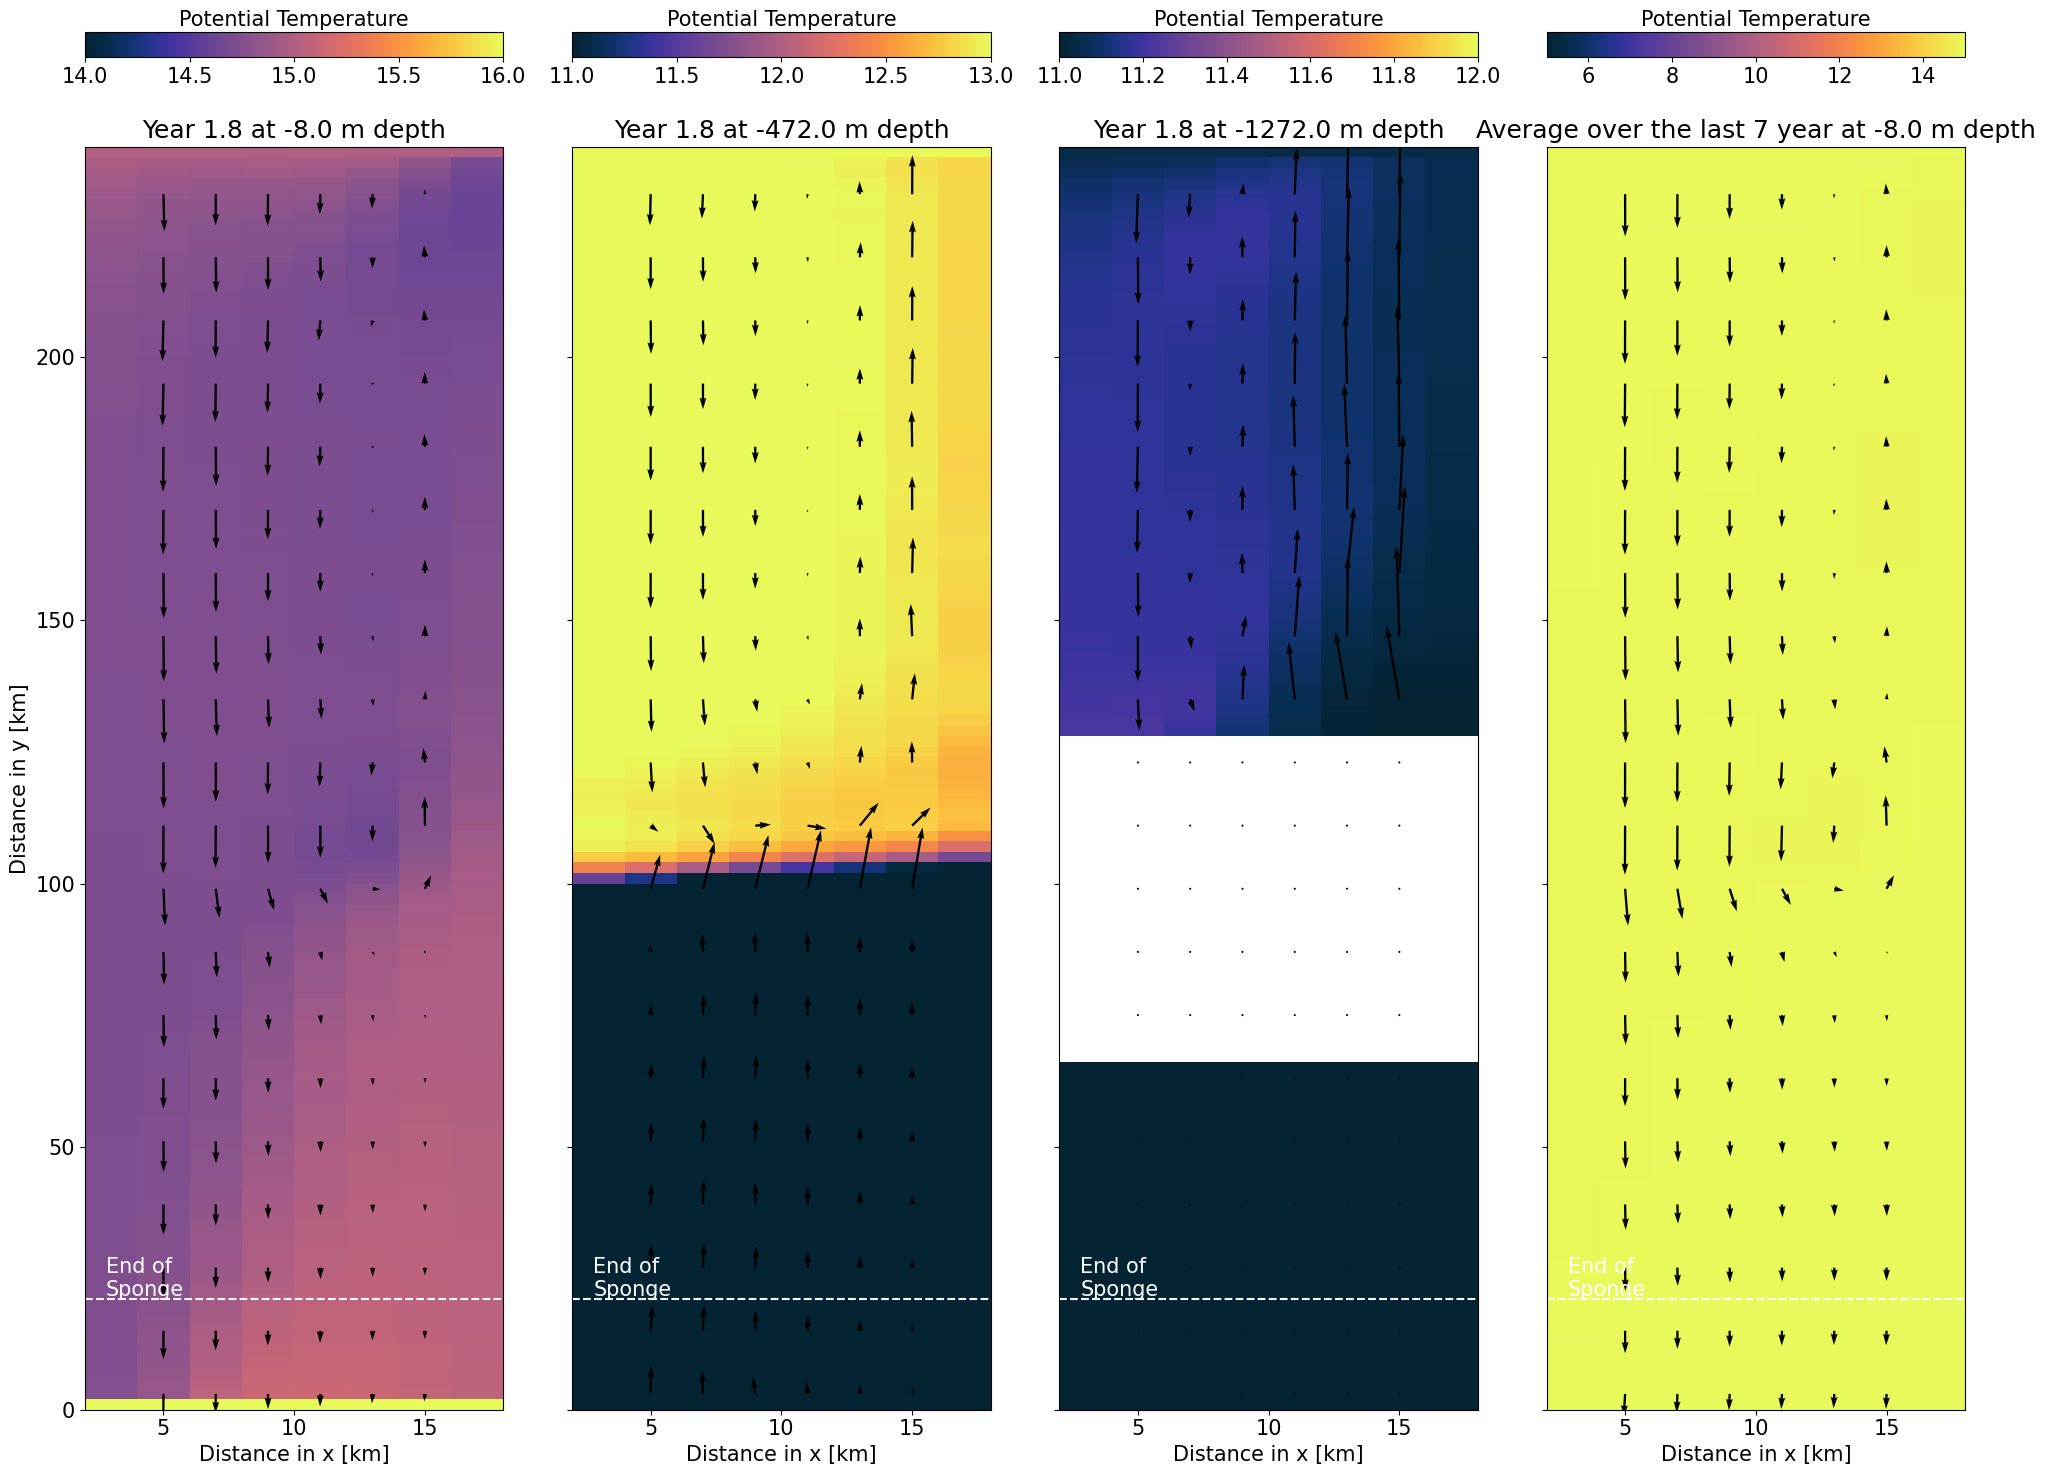

In [31]:
t=0
space=6
dep=[0,29,-1]
VARS=list(ds.keys())[2:]


#for variable in VARS:

variable=VARS[0]

exec(f'varin=ds.{variable}')
title= varin.description 

Yin=dsG.Y
Xin=dsG.X[OBx:OBendx]

cmapi=cmocean.cm.thermal

fig,ax=plt.subplots(1,4)


tin=end-3


axin=ax[0]
vmin=14 #np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
vmax=16 #-np.min(np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]))
axin.set(xlabel='Distance in x [km]',ylabel='Distance in y [km]')

timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[0],:,OBx:OBendx],mask=mask[dep[0],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[0]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((ds.Yp1.values,ds.X.values),ds.VVEL[tin,dep[0],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((ds.Y.values,ds.Xp1.values),ds.UVEL[tin,dep[0],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

if project =='OpenNorth':
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
    axin.axhline(ds.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
else:
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[1]

vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
vmax=13 #-np.min(np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[1],:,OBx:OBendx],mask=mask[dep[1],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[1]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((ds.Yp1.values,ds.X.values),ds.VVEL[tin,dep[1],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((ds.Y.values,ds.Xp1.values),ds.UVEL[tin,dep[1],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

if project =='OpenNorth':
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
    axin.axhline(ds.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
else:
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[2]

vmin=11 #np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
vmax=12 # -np.min(np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]))
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(varin[tin,dep[2],:,OBx:OBendx],mask=mask[dep[2],:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.set(title=f'Year {timein/360:.1f} at {dsG.Z[dep[2]]:.1f} m depth')


gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((ds.Yp1.values,ds.X.values),ds.VVEL[tin,dep[2],:,:].values)
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((ds.Y.values,ds.Xp1.values),ds.UVEL[tin,dep[2],:,:].values)
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])

if project =='OpenNorth':
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
    axin.axhline(ds.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
else:
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

axin=ax[3]

vmin= 5#np.min(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
vmax= 15#np.max(np.mean(np.ma.masked_array(np.mean(varin[start:,:,:,OBx:OBendx],axis=0),mask=mask[:,:,OBx:OBendx]),axis=0))/10
axin.yaxis.set_tick_params(labelleft=False)
axin.set(xlabel='Distance in x [km]')


indmean=0
timein=ds.T[tin]/(60*60*24)
cax=axin.pcolormesh(Xin/1000, Yin/1000, np.ma.masked_array(np.mean(varin[start:end,indmean,:,OBx:OBendx],axis=0),mask=mask[indmean,:,OBx:OBendx]),vmin=vmin,vmax=vmax,cmap=cmapi)
axin.contour(Xin/1000, Yin/1000, np.ma.masked_array(np.mean(varin[start:end,indmean,:,OBx:OBendx],axis=0),mask=mask[indmean,:,OBx:OBendx]),levels=[0], colors='k')

gridY,gridX=np.meshgrid(Yin[1:-1].values,Xin[OBx:OBendx].values)

interpV=sciint.RegularGridInterpolator((ds.Yp1.values,ds.X.values),np.mean(ds.VVEL[start:end,indmean,:,:].values,axis=0))
V=interpV((gridY,gridX))

interpU=sciint.RegularGridInterpolator((ds.Y.values,ds.Xp1.values),np.mean(ds.UVEL[start:end,indmean,:,:].values,axis=0))
U=interpU((gridY,gridX))

axin.quiver(gridX[:,np.arange(0,len(gridY[0,:]),space)]/1000,gridY[:,np.arange(0,len(gridY[0,:]),space)]/1000,U[:,np.arange(0,len(gridY[0,:]),space)],V[:,np.arange(0,len(gridY[0,:]),space)])


axin.set(title=f'Average over the last 7 year at {dsG.Z[indmean].values:.1f} m depth')

if project =='OpenNorth':
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09,'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
    axin.axhline(ds.Y[OBend]/1000,c='white',linestyle='dashed')
    axin.text( 0.05,0.89, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)
else:
    axin.axhline(ds.Y[OB]/1000,c='white',linestyle='dashed')
    axin.text( 0.05, 0.09, 'End of \nSponge', color='white', 
        transform=axin.transAxes,fontsize=15)

divider = make_axes_locatable(axin)
axdiv = divider.new_vertical(size = '2%', pad = 0.9)
fig.add_axes(axdiv)
cbar_ax = plt.colorbar(cax, cax=axdiv,orientation='horizontal')
cbar_ax.ax.xaxis.set_label_position("top")
cbar_ax.set_label(title)

fig.tight_layout()

fig.patch.set_alpha(0.0)
#plt.savefig('../' + str(project)+'/Figures/' + str(ed)+ 'WvelDifDepths.png', bbox_inches='tight')